# Voorspellen van de bloeddruk op basis van gewicht en leeftijd

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import linear_model

In [ ]:
# Inlezen van de dataset
data_bd = pd.read_csv('data/bloeddruk.csv')

In [3]:
# Dimensie van de dataset
print(data_bd.shape)

(11, 3)


In [4]:
# Toon de eerste rijen van de dataset
data_bd.head(11)

,leeftijd,gewicht,bloeddruk
0,52,78,136
1,59,83,143
2,67,88,153
3,73,96,162
4,64,89,161
5,74,103,171
6,54,85,137
7,61,85,149
8,65,94,162
9,46,76,128


In [5]:
# Statistische eigenschappen van de dataset
data_bd.describe()

,leeftijd,gewicht,bloeddruk
count,11.000000,11.000000,11.000000
mean,62.454545,88.636364,151.636364
std,9.114424,8.417514,14.087390
min,46.000000,76.000000,128.000000
25%,56.500000,84.000000,140.000000
50%,64.000000,88.000000,153.000000
75%,69.500000,95.000000,162.000000
max,74.000000,103.000000,171.000000


In [6]:
# Bereken de onderlingen correlatiecoëfficiënten
data_bd.corr()

,leeftijd,gewicht,bloeddruk
leeftijd,1.000000,0.936927,0.955477
gewicht,0.936927,1.000000,0.947494
bloeddruk,0.955477,0.947494,1.000000


<Axes: title={'center': 'Bloeddruk als functie van het gewicht'}, xlabel='gewicht', ylabel='bloeddruk'>

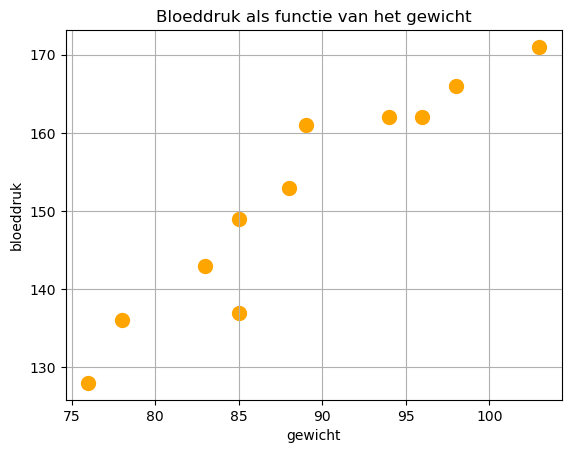

In [7]:
# Scatterplot tussen gewicht en bloeddruk
data_bd.plot(kind='scatter',x='gewicht',y='bloeddruk',title='Bloeddruk als functie van het gewicht',grid=True,s=100,color='orange')

<Axes: title={'center': 'Bloeddruk als functie van de leeftijd'}, xlabel='leeftijd', ylabel='bloeddruk'>

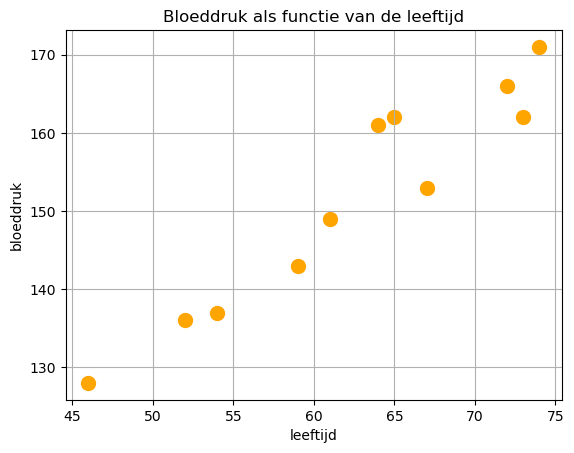

In [8]:
# Scatterplot tussen leeftijd en bloeddruk
data_bd.plot(kind='scatter',x='leeftijd',y='bloeddruk',title='Bloeddruk als functie van de leeftijd',grid=True,s=100,color='orange')

In [9]:
# Opsplitsen in features en targets
features = list(data_bd.columns[:2])
print(features)
X = data_bd[features].values
y= data_bd['bloeddruk'].values

print(X[:,0].reshape(-1,1))

['leeftijd', 'gewicht']
[[52]
 [59]
 [67]
 [73]
 [64]
 [74]
 [54]
 [61]
 [65]
 [46]
 [72]]


teta0=  [59.40347997]
teta1= [[1.47680018]]


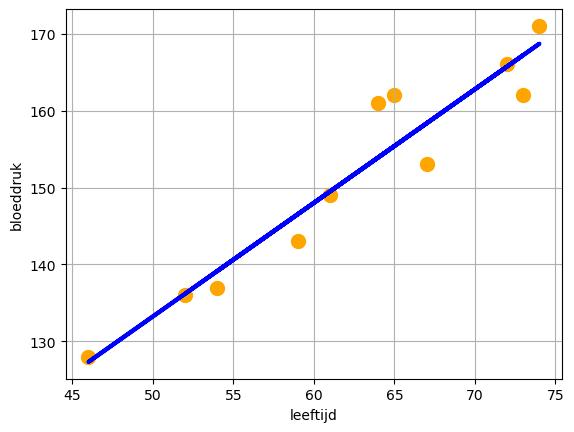

In [10]:
# Train een linear regression model tussen leeftijd en bloeddruk

leeftijden = X[:,0].reshape(-1,1)

clf_leeftijd = linear_model.LinearRegression()
clf_leeftijd.fit(leeftijden,y.reshape(-1,1))

data_bd.plot(kind='scatter',x='leeftijd',y='bloeddruk',s=100,grid=True,color='orange')
plt.plot(leeftijden,clf_leeftijd.predict(leeftijden), color='blue',linewidth=3)
print('teta0= ',clf_leeftijd.intercept_)
print('teta1=' ,clf_leeftijd.coef_)

In [11]:
# Voorspel de bloeddruk van een persoon met een leeftijd van 72 jaar
# np.array([[72]]) maakt een 2D array met één rij en één kolom want we willen 1 sample met 1 feature laten voorspellen,
# maar de predict functie verwacht een 2D array als input. 
print('Voorspelde bloeddruk= ',clf_leeftijd.predict(np.array([[72]])))
print('teta0= ',clf_leeftijd.intercept_)
print('teta1=' ,clf_leeftijd.coef_)
print()
print('bloeddruk =', clf_leeftijd.coef_[0,0] ,' * leeftijd +', clf_leeftijd.intercept_[0])


Voorspelde bloeddruk=  [[165.73309258]]
teta0=  [59.40347997]
teta1= [[1.47680018]]

bloeddruk = 1.4768001750930178  * leeftijd + 59.40347997373607


teta0=  [11.08506543]
teta1= [[1.58570695]]

bloeddruk = 1.5857069540672306 * gewicht + 11.085065434949996


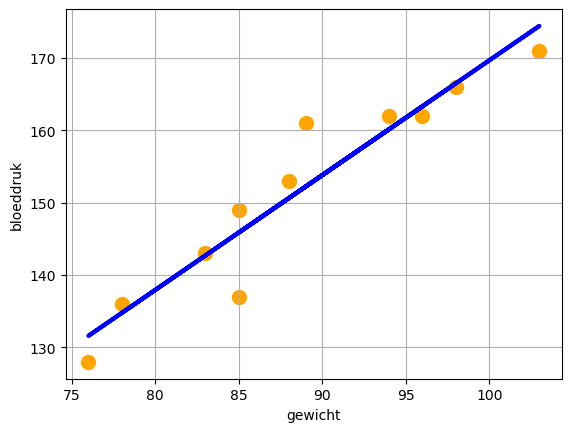

In [12]:
# Train een linear regression model tussen gewicht en bloeddruk

gewichten = X[:,1].reshape(-1,1)

clf_gewicht = linear_model.LinearRegression()
clf_gewicht.fit(gewichten,y.reshape(-1,1))
data_bd.plot(kind='scatter',x='gewicht',y='bloeddruk',s=100,grid=True,color='orange')
plt.plot(gewichten,clf_gewicht.predict(gewichten), color='blue',linewidth=3)
print('teta0= ',clf_gewicht.intercept_)
print('teta1=' ,clf_gewicht.coef_)
print()
print('bloeddruk =', clf_gewicht.coef_[0,0] ,'* gewicht +', clf_gewicht.intercept_[0])

In [13]:
# Voorspel de bloeddruk van een persoon met een gewicht van 91 kg
print('Voorspelde bloeddruk= ',clf_gewicht.predict(np.array([[91]])))
print('teta0= ',clf_gewicht.intercept_)
print('teta1=' ,clf_gewicht.coef_)

print('bloeddruk =', clf_gewicht.coef_[0,0] ,'* gewicht +', clf_gewicht.intercept_[0])

Voorspelde bloeddruk=  [[155.38439826]]
teta0=  [11.08506543]
teta1= [[1.58570695]]
bloeddruk = 1.5857069540672306 * gewicht + 11.085065434949996


In [14]:
# Train een linear regression model tussen alle features (gewicht en leeftijd) en de bloeddruk

clf = linear_model.LinearRegression()
clf.fit(X,y)

print('teta0= ',clf.intercept_)
print('teta1=' ,clf.coef_[0])
print('teta2=' ,clf.coef_[1])
print()
print('bloeddruk =', clf.coef_[0] ,'* leeftijd +', clf.coef_[1] ,'* gewicht +',clf.intercept_)

teta0=  34.62648847714206
teta1= 0.8570834381593766
teta2= 0.7161972356266109

bloeddruk = 0.8570834381593766 * leeftijd + 0.7161972356266109 * gewicht + 34.62648847714206


In [15]:
# Voorspel de bloeddruk van iemand met een leeftijd van 24 jaar en een gewicht van 86kg

X_test = np.array([24,86]).reshape(1, -1)

print('Voorspelde bloeddruk= ',clf.predict(X_test))
print()
print('bloeddruk =', clf.coef_[0] ,'* leeftijd +', clf.coef_[1] ,'* gewicht +',clf.intercept_)

Voorspelde bloeddruk=  [116.78945326]

bloeddruk = 0.8570834381593766 * leeftijd + 0.7161972356266109 * gewicht + 34.62648847714206
